### 01 — Download & Load the Dataset

In [32]:
import re

# 1. Text cleaning function
def clean_text(text):
    text = text.lower()                         # Lowercase කිරීම
    text = re.sub(r'[^a-z\s]', '', text)       # Punctuation, numbers, symbols අයින් කිරීම
    text = re.sub(r'\s+', ' ', text).strip()   # Extra spaces අයින් කිරීම
    return text

# 2. 'clean_text' කියලා අලුත් column එකක් හදාගැනීම
df['clean_text'] = df['text'].apply(clean_text)

# 3. Original text එකයි cleaned text එකයි compare කරලා බැලීම
print("--- Comparison: Original vs Preprocessed Text ---")
df[['text', 'clean_text', 'sentiment']].head()

--- Comparison: Original vs Preprocessed Text ---


,text,clean_text,sentiment
0,Wow... Loved this place.,wow loved this place,1
1,Crust is not good.,crust is not good,0
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty,0
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...,1
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...,1


In [23]:
import os
import zipfile
import pandas as pd

# 1. Define paths
zip_path = r"C:\Users\ASUS\Desktop\ml train\sentiment+labelled+sentences.zip"
extract_dir = r"C:\Users\ASUS\Desktop\ml train\extracted_sentiment"

# 2. Extract ZIP archive
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

base_path = os.path.join(extract_dir, "sentiment labelled sentences")

# 3. Load all 3 files and combine them into one DataFrame
files = ['yelp_labelled.txt', 'amazon_cells_labelled.txt', 'imdb_labelled.txt']
dfs = []

for file in files:
    file_path = os.path.join(base_path, file)
    temp_df = pd.read_csv(file_path, sep='\t', header=None, names=['text', 'sentiment'])
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

# 4. Inspect dataset
print("Dataset Shape:", df.shape)
print("\nClass Distribution (0 = Negative, 1 = Positive):")
print(df['sentiment'].value_counts())
df.head()

Dataset Shape: (2748, 2)

Class Distribution (0 = Negative, 1 = Positive):
sentiment
1    1386
0    1362
Name: count, dtype: int64


,text,sentiment
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [24]:
import re

# 1. Preprocessing function
def clean_text(text):
    text = text.lower()                         # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)       # Remove punctuation, symbols & numbers
    text = re.sub(r'\s+', ' ', text).strip()   # Remove extra whitespaces
    return text

# 2. Create clean_text column
df['clean_text'] = df['text'].apply(clean_text)

# 3. Compare original vs clean text
print("--- Comparison of Original vs Cleaned Text ---")
df[['text', 'clean_text', 'sentiment']].head()

--- Comparison of Original vs Cleaned Text ---


,text,clean_text,sentiment
0,Wow... Loved this place.,wow loved this place,1
1,Crust is not good.,crust is not good,0
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty,0
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...,1
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...,1


### 03 — Explore the Text Data

--- Positive Review Examples ---
+ wow loved this place
+ stopped by during the late may bank holiday off rick steve recommendation and loved it
+ the selection on the menu was great and so were the prices

--- Negative Review Examples ---
- crust is not good
- not tasty and the texture was just nasty
- now i am getting angry and i want my damn pho


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22648\3497469171.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=[count for _, count in pos_common], y=[word for word, _ in pos_common], palette="Greens_r")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22648\3497469171.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=[count for _, count in neg_common], y=[word for word, _ in neg_common], palette="Reds_r")


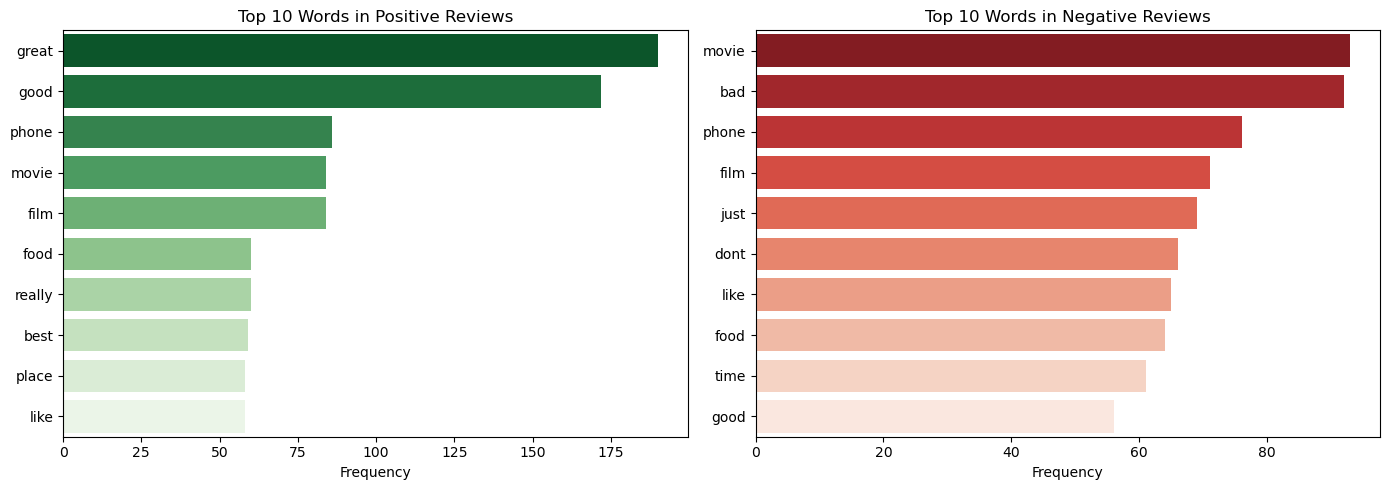

In [25]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 1. Display positive and negative examples
print("--- Positive Review Examples ---")
for sent in df[df['sentiment'] == 1]['clean_text'].head(3):
    print(f"+ {sent}")

print("\n--- Negative Review Examples ---")
for sent in df[df['sentiment'] == 0]['clean_text'].head(3):
    print(f"- {sent}")

# 2. Identify frequently occurring words (excluding stop words)
pos_words = [w for w in " ".join(df[df['sentiment'] == 1]['clean_text']).split() if w not in ENGLISH_STOP_WORDS]
neg_words = [w for w in " ".join(df[df['sentiment'] == 0]['clean_text']).split() if w not in ENGLISH_STOP_WORDS]

pos_common = Counter(pos_words).most_common(10)
neg_common = Counter(neg_words).most_common(10)

# 3. Plot top words
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(ax=axes[0], x=[count for _, count in pos_common], y=[word for word, _ in pos_common], palette="Greens_r")
axes[0].set_title("Top 10 Words in Positive Reviews")
axes[0].set_xlabel("Frequency")

sns.barplot(ax=axes[1], x=[count for _, count in neg_common], y=[word for word, _ in neg_common], palette="Reds_r")
axes[1].set_title("Top 10 Words in Negative Reviews")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

 ### 04 — Split the Dataset

In [26]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

# 80% Train, 20% Test with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total samples   : {len(df)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Total samples   : 2748
Training samples: 2198
Testing samples : 550


### 05 — Create Bag of Words (BOW) Representation

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer (removes standard English stop words)
bow_vectorizer = CountVectorizer(stop_words='english')

# Fit on training data and transform both train and test sets
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Vocabulary Size :", len(bow_vectorizer.vocabulary_))
print("X_train_bow Shape:", X_train_bow.shape)
print("X_test_bow Shape :", X_test_bow.shape)

Vocabulary Size : 4407
X_train_bow Shape: (2198, 4407)
X_test_bow Shape : (550, 4407)


### 06 — Train Machine Learning Models

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bow, y_train)
lr_pred = lr_model.predict(X_test_bow)

# 2. Linear Support Vector Machine (SVM)
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_bow, y_train)
svm_pred = svm_model.predict(X_test_bow)

print("Models trained successfully!")

Models trained successfully!


### 07 — Evaluate Model Performance

================ Logistic Regression ================
Accuracy  : 0.8055
Precision : 0.8172
Recall    : 0.7906
F1-Score  : 0.8037

Classification Report:
               precision    recall  f1-score   support

    Negative       0.79      0.82      0.81       273
    Positive       0.82      0.79      0.80       277

    accuracy                           0.81       550
   macro avg       0.81      0.81      0.81       550
weighted avg       0.81      0.81      0.81       550

================ Support Vector Machine (SVM) ================
Accuracy  : 0.7818
Precision : 0.7875
Recall    : 0.7762
F1-Score  : 0.7818

Classification Report:
               precision    recall  f1-score   support

    Negative       0.78      0.79      0.78       273
    Positive       0.79      0.78      0.78       277

    accuracy                           0.78       550
   macro avg       0.78      0.78      0.78       550
weighted avg       0.78      0.78      0.78       550



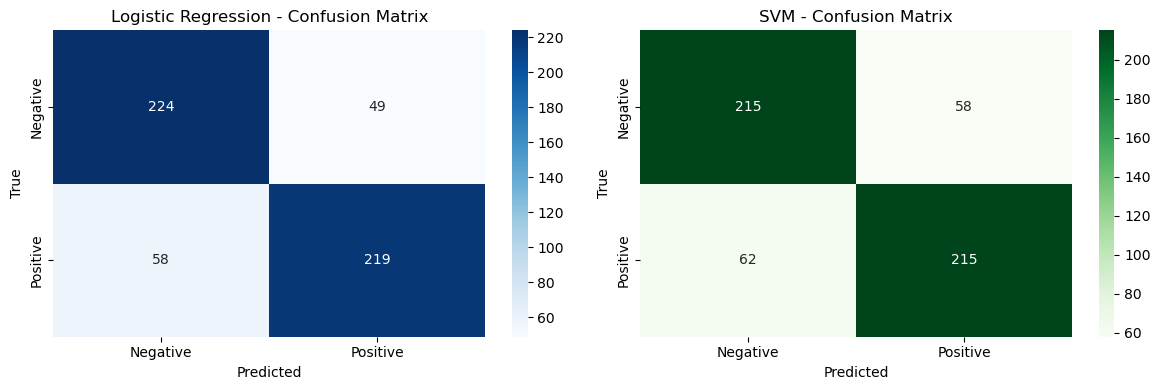

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(name, y_true, y_pred):
    print(f"================ {name} ================")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# Metrics output
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Support Vector Machine (SVM)", y_test, svm_pred)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_title("SVM - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

### 08 — Test with New Sentences

In [30]:
# Helper function for test sentences
def predict_sentiment(text, model, vectorizer):
    cleaned = clean_text(text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]
    
    confidence = None
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(features)[0]
        confidence = prob[prediction] * 100

    sentiment_label = "Positive" if prediction == 1 else "Negative"
    return sentiment_label, confidence

# Test sentences list
test_sentences = [
    "The customer service was exceptional and the staff were very friendly.",
    "Waste of money and completely useless.",
    "Best purchase I have made all year, works flawlessly!",
    "The storyline was boring and predictable from start to finish.",
    "The device overheats within ten minutes and shuts down.",
    "Not good at all, very disappointed."
]

print("--- Sentiment Predictions ---")
for sentence in test_sentences:
    label, conf = predict_sentiment(sentence, lr_model, bow_vectorizer)
    print(f"Sentence   : \"{sentence}\"")
    print(f"Prediction : {label} ({conf:.2f}% confidence)")
    print("-" * 60)

--- Sentiment Predictions ---
Sentence   : "The customer service was exceptional and the staff were very friendly."
Prediction : Positive (80.33% confidence)
------------------------------------------------------------
Sentence   : "Waste of money and completely useless."
Prediction : Negative (99.03% confidence)
------------------------------------------------------------
Sentence   : "Best purchase I have made all year, works flawlessly!"
Prediction : Positive (95.33% confidence)
------------------------------------------------------------
Sentence   : "The storyline was boring and predictable from start to finish."
Prediction : Negative (81.38% confidence)
------------------------------------------------------------
Sentence   : "The device overheats within ten minutes and shuts down."
Prediction : Negative (79.08% confidence)
------------------------------------------------------------
Sentence   : "Not good at all, very disappointed."
Prediction : Positive (55.78% confidence)
----

In [31]:
import re

# 1. Text cleaning function
def clean_text(text):
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)       # Remove punctuation, numbers, and symbols
    text = re.sub(r'\s+', ' ', text).strip()   # Remove extra whitespace
    return text

# 2. Apply function to the text column
df['clean_text'] = df['text'].apply(clean_text)

# 3. Keep ONLY the single clean_text column
clean_df_only = df[['clean_text']]

# 4. Display the first 10 rows
clean_df_only.head(10)

,clean_text
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...
5,now i am getting angry and i want my damn pho
6,honeslty it didnt taste that fresh
7,the potatoes were like rubber and you could te...
8,the fries were great too
9,a great touch


### Custom Stop Words Handling (Preserving Negations)

In [33]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Standard English stop words ලබාගැනීම
stop_words = set(stopwords.words('english'))

# Sentiment එකට critical වෙන negation words ටික stop words වලින් අයින් කිරීම
negation_words = {'not', 'no', 'never', 'nor', 'neither', 'barely', 'hardly', 'scarcely'}
custom_stop_words = stop_words - negation_words

def remove_stopwords(text):
    words = text.split()
    # Negation words තියාගෙන අනිත් stop words පමණක් filter කිරීම
    filtered_words = [w for w in words if w not in custom_stop_words]
    return ' '.join(filtered_words)

# Apply stop words removal to our clean_text
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

# Before vs After check
df[['clean_text', 'sentiment']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,clean_text,sentiment
0,wow loved place,1
1,crust not good,0
2,not tasty texture nasty,0
3,stopped late may bank holiday rick steve recom...,1
4,selection menu great prices,1


### Pipeline Code

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Pipeline එකක් නිර්මාණය කිරීම: Step 1 = Vectorizer, Step 2 = Model
nlp_pipeline = Pipeline([
    ('bow', CountVectorizer(stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Training data එක කෙලින්ම pipeline එකට ලබා දී train කිරීම
nlp_pipeline.fit(X_train, y_train)

# Test data මඟින් predictions ලබා ගැනීම
pipeline_pred = nlp_pipeline.predict(X_test)

print("Pipeline Test Accuracy:", (pipeline_pred == y_test).mean())

Pipeline Test Accuracy: 0.8054545454545454


### AutoML

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# 1. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.20, random_state=42, stratify=df['sentiment']
)

# 2. Text Representation
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


best_model_name = None
best_accuracy = 0.0
best_model = None

print("--- AutoML Model Evaluation ---")
for name, model in candidate_models.items():
   
    model.fit(X_train_vec, y_train)
   
    preds = model.predict(X_test_vec)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(f"{name:<25} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = model

print("-" * 50)
print(f"🏆 Best Model Selected by AutoML: {best_model_name} with Accuracy: {best_accuracy:.4f}")

--- AutoML Model Evaluation ---
Logistic Regression       | Accuracy: 0.8109 | F1-Score: 0.8129
Linear SVM                | Accuracy: 0.7927 | F1-Score: 0.8007
Multinomial Naive Bayes   | Accuracy: 0.8000 | F1-Score: 0.8116
Random Forest             | Accuracy: 0.7727 | F1-Score: 0.7818
--------------------------------------------------
🏆 Best Model Selected by AutoML: Logistic Regression with Accuracy: 0.8109


In [35]:
!pip install tpot

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 15.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 20.6 MB/s eta 0:00:03
   - -------------------------------------- 2.4/48.9 MB 5.1 MB/s eta 0:00:10
   - -------------------------------------- 2.4/48.9 MB 5.1 MB/s eta 0:00:10
   -- ------------------------------------- 3.4/48.9 MB 3.7 MB/s eta 0:00:13
   -- ------------------------------------- 3.7/48.9 MB 3.7 MB/s eta 0:00:13
   -- ------------------------------------- 3.7/48.9 MB 3.7 MB/s eta 0:00:13
   --- ------------------------------------ 4.5/48.9 MB 3.0 MB/s eta 0:00:15
   --- ---------------------------------

  DEPRECATION: Building 'func-timeout' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'func-timeout'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'stopit' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'stopit'. Discussion can be found at https://github.com/pypa/pip/issues/6334
